In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

import matplotlib.pyplot as plt

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv(r"C:\Users\Baku\Downloads\cars.csv")

# ----------------------------


In [22]:
# 2. Preprocessing


# ID useless → drop
df = df.drop(columns=["ID"])


df = df.dropna()


le = LabelEncoder()

categorical_cols = [
    "Model",
    "Condition",
    "Fuel Type",
    "Seller Type",
    "Location",
    "Transmission",
    "Color"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])



=== RESULTS ===
MAE  : 4983.19
RMSE : 9178.23
R²   : 0.6171


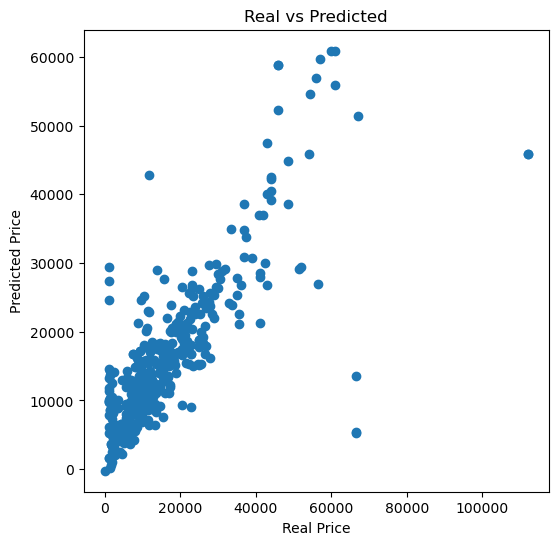


=== FEATURE IMPORTANCE ===
Model: 43.92
Year: 21.19
Condition: 2.68
Fuel Type: 6.38
Mileage: 6.41
Seller Type: 4.71
Location: 10.71
Insurance: 0.34
Transmission: 0.51
Color: 3.14


In [38]:

# 3. Features & Target

X = df.drop(columns=["Price"])
y = df["Price"]

# ----------------------------
# 4. Train/Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 5. Model
# ----------------------------
model = CatBoostRegressor(verbose=0)
model.fit(X_train, y_train)

# ----------------------------
# 6. Prediction
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# 7. Evaluation
# ----------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== RESULTS ===")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# ----------------------------
# 8. Real vs Predicted plot
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Real Price")
plt.ylabel("Predicted Price")
plt.title("Real vs Predicted")
plt.show()

# ----------------------------
# 9. Feature Importance
# ----------------------------
importances = model.get_feature_importance()
features = X.columns

print("\n=== FEATURE IMPORTANCE ===")
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.2f}")

In [23]:
df["Price"]=df["Price"].str.replace(" JOD","").str.replace(",","").astype(int)

In [25]:
df["Mileage"]= df["Mileage"].str.replace("km", "").str.replace(",",  "").str.replace(" ", "").str.replace("KM", "")

In [29]:
m = df["Mileage"].str.split('-', expand = True)

In [30]:
df["Mileage"]=(m[0].astype(float) + m[1].astype(float))/2

In [34]:
df[df["Mileage"]==""]=0

In [35]:
df

,Model,Year,Condition,Fuel Type,Mileage,Seller Type,Location,Price,Insurance,Transmission,Color
0,532,2023,1,0,74999.5,3,202,22500,No insurance,0,18
1,49,2020,1,3,104999.5,4,118,64399,No insurance,0,5
2,416,2020,0,3,44999.5,1,13,9500,No insurance,0,8
3,560,2014,1,3,104999.5,4,42,53000,No insurance,0,18
4,259,2021,0,3,34999.5,1,78,37000,No insurance,0,5
...,...,...,...,...,...,...,...,...,...,...,...
2090,424,2006,1,3,NaN,4,101,4300,Insurance is available.,0,5
2091,505,2009,1,3,NaN,4,42,1700,No insurance,0,18
2092,108,1997,1,3,94999.5,4,88,1000,No insurance,0,18
2093,154,2018,1,0,154999.5,3,16,10500,No insurance,0,6


In [37]:
df["Insurance"] = df["Insurance"].apply(lambda x: 1 if x != "No insurance" else 0)